In [169]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: xgboost in c:\users\tanuja\appdata\local\programs\python\python310\lib\site-packages (3.2.0)




[notice] A new release of pip is available: 23.3.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Problem Statement

# 1. Import Liberaries

In [170]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,silhouette_score


from sklearn.decomposition import PCA

# 2. Load Dataset

In [171]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# 3. Data Preprocessing

### Dataset Information

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


### Checking null values

In [173]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

### Checking Duplicate values

In [174]:
df.duplicated().sum()

0

### Remove extra spaces in column names

In [175]:
df.columns = df.columns.str.strip()

### Convert all numeric columns

In [176]:
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [177]:
df.fillna(df.median(numeric_only=True), inplace=True)

print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


# 4. EDA

In [178]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [179]:
X = df.drop("country", axis=1)

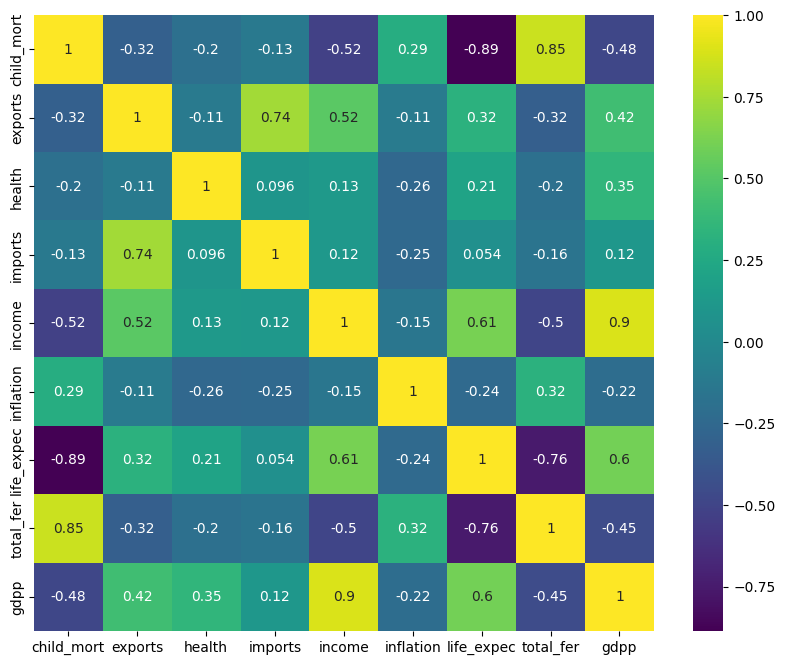

In [180]:
plt.figure(figsize=(10,8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="viridis"
)

plt.show()

## Standardize Features

In [181]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 5. Elbow Method

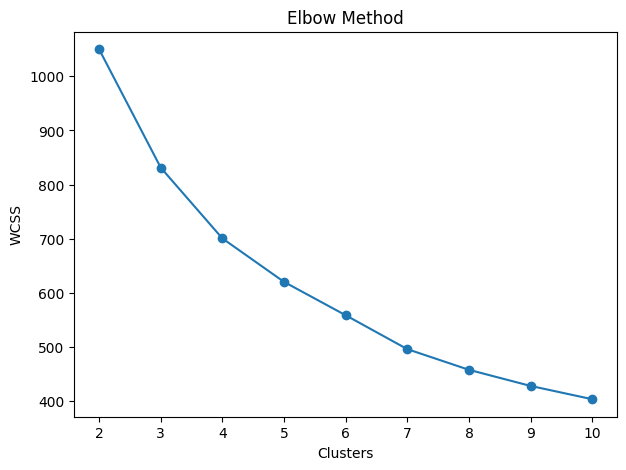

In [182]:
wcss = []

for i in range(2,11):

    km = KMeans(n_clusters=i,random_state=42,n_init=10)

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(2,11),wcss,marker='o')

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# 6.KMeans Clustering

In [183]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)

cluster_labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = cluster_labels

# 7.Silhouette Score

In [184]:
score = silhouette_score(X_scaled,cluster_labels)

print("Silhouette Score:",score)

Silhouette Score: 0.28329575683463126


# 8.Cluster Distribution

In [185]:
print(df["Cluster"].value_counts())

2    84
1    47
0    36
Name: Cluster, dtype: int64


# 9.PCA Visualization

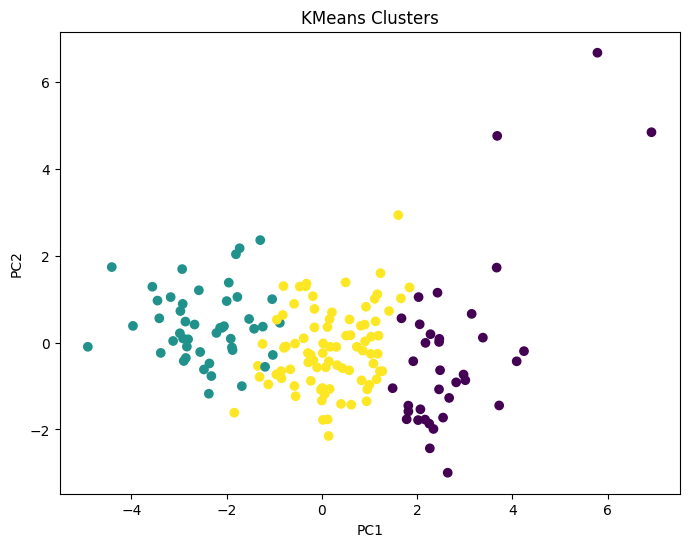

In [186]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap='viridis'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters")

plt.show()

# 10.DBSCAN

In [187]:
db = DBSCAN(eps=1.5,min_samples=5)

db_labels = db.fit_predict(X_scaled)

df["DBSCAN"] = db_labels

print(df["DBSCAN"].value_counts())

 0    137
-1     30
Name: DBSCAN, dtype: int64


# 11.DBSCAN Visualization

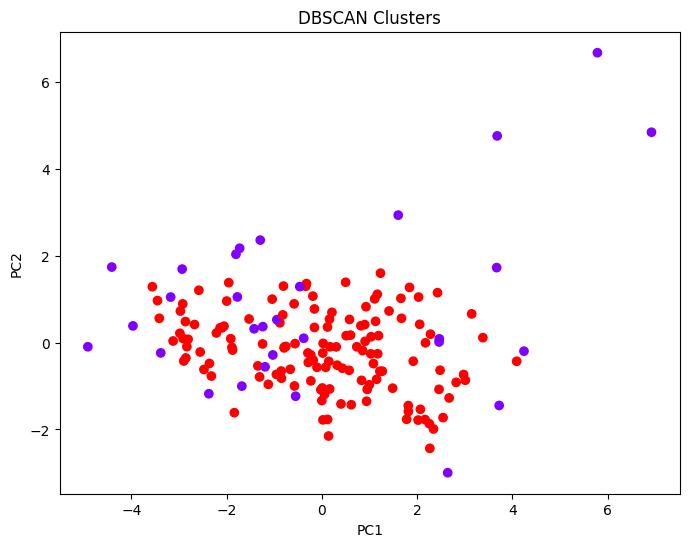

In [188]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],X_pca[:,1],c=db_labels,cmap='rainbow')

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("DBSCAN Clusters")

plt.show()

# 12.Feature Engineering

In [189]:
X = X_scaled

y = cluster_labels

# 13.Train Test Split

In [190]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# 14.Model Training

In [191]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42,n_estimators=200),

    "XGBoost": XGBClassifier(random_state=42,eval_metric="mlogloss")
}

# 15.Model Evalution

In [192]:
results = []

for name, model in models.items():

    train_start = time.perf_counter()

    model.fit(X_train,y_train)

    train_end = time.perf_counter()

    pred_start = time.perf_counter()

    pred = model.predict(X_test)

    pred_end = time.perf_counter()

    accuracy = accuracy_score(y_test,pred)

    precision = precision_score(y_test,pred,average="weighted")

    recall = recall_score(y_test,pred,average="weighted")

    f1 = f1_score(y_test,pred,average="weighted")

    results.append({

        "Model":name,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1 Score":f1,

    })

    print("\n",name)

    print(classification_report(y_test,pred))


 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


 Decision Tree
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.90      0.95        10
           2       0.94      0.94      0.94        17

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.94      0.94      0.94        34


 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.

# 16.Model Comparison Table

In [193]:
comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.941176,0.944853,0.941176,0.941383
2,Random Forest,1.000000,1.000000,1.000000,1.000000
3,XGBoost,0.941176,0.947368,0.941176,0.940905


# 17.Cross Validation

In [194]:
for name, model in models.items():

    scores = cross_val_score(model,X,y,cv=5,scoring="accuracy")

    print(name)

    print(scores)

    print("Average Accuracy:",scores.mean())

    print()

Logistic Regression
[0.94117647 1.         1.         0.90909091 0.93939394]
Average Accuracy: 0.9579322638146168

Decision Tree
[0.91176471 1.         0.90909091 0.87878788 0.90909091]
Average Accuracy: 0.9217468805704099

Random Forest
[0.97058824 1.         0.93939394 0.90909091 0.96969697]
Average Accuracy: 0.9577540106951872

XGBoost
[0.94117647 1.         0.93939394 0.93939394 0.96969697]
Average Accuracy: 0.9579322638146168



# 18.Feature Importance

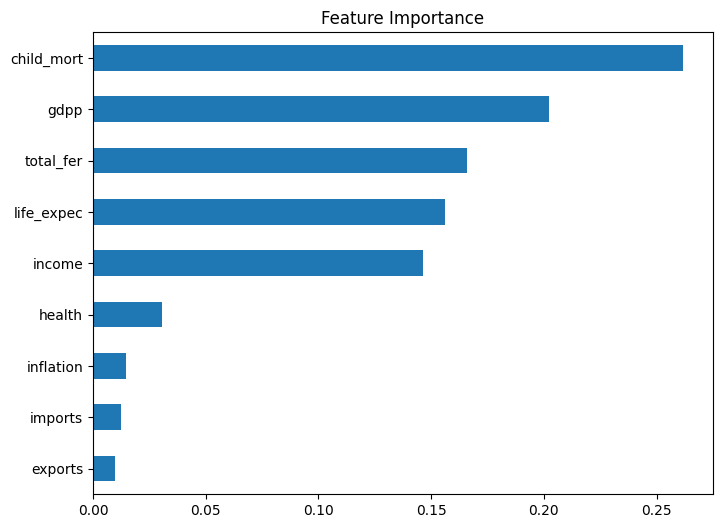

In [195]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

rf.fit(X_train,y_train)

importance = pd.Series(

    rf.feature_importances_,

    index=df.drop(
        ["country","Cluster","DBSCAN"],
        axis=1
    ).columns

)

importance.sort_values().plot(

    kind="barh",

    figsize=(8,6)

)

plt.title("Feature Importance")

plt.show()

# 19.Observations